In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("data/insurance.csv")

In [3]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB
None


In [4]:
print(df.isnull().sum())

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [5]:
print(df.head())

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


In [6]:
print(df.nunique())

age           47
sex            2
bmi          548
children       6
smoker         2
region         4
charges     1337
dtype: int64


In [7]:
num_cols=["age","bmi","children","charges"]
desc=df[num_cols].describe()
print(desc)

print(df[num_cols].skew())
print(df[num_cols].kurt())

               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.296250     0.000000   4740.287150
50%      39.000000    30.400000     1.000000   9382.033000
75%      51.000000    34.693750     2.000000  16639.912515
max      64.000000    53.130000     5.000000  63770.428010
age         0.055673
bmi         0.284047
children    0.938380
charges     1.515880
dtype: float64
age        -1.245088
bmi        -0.050732
children    0.202454
charges     1.606299
dtype: float64


In [8]:
print(df.groupby("smoker")["charges"].describe())

         count          mean           std         min           25%  \
smoker                                                                 
no      1064.0   8434.268298   5993.781819   1121.8739   3986.438700   
yes      274.0  32050.231832  11541.547176  12829.4551  20826.244213   

                50%           75%          max  
smoker                                          
no       7345.40530  11362.887050  36910.60803  
yes     34456.34845  41019.207275  63770.42801  


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

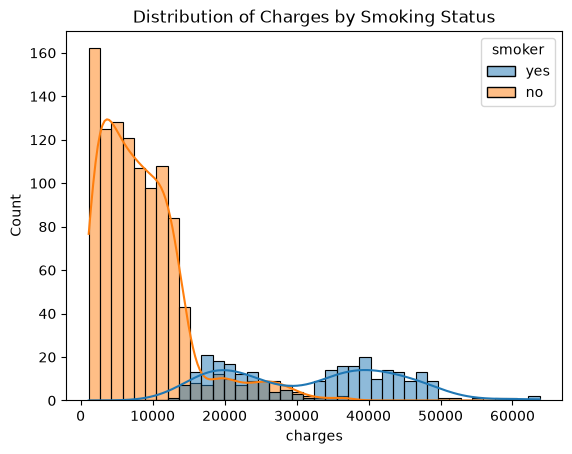

In [10]:
sns.histplot(data=df,x="charges",hue="smoker",kde=True,bins=40)
plt.title("Distribution of Charges by Smoking Status")
plt.show()

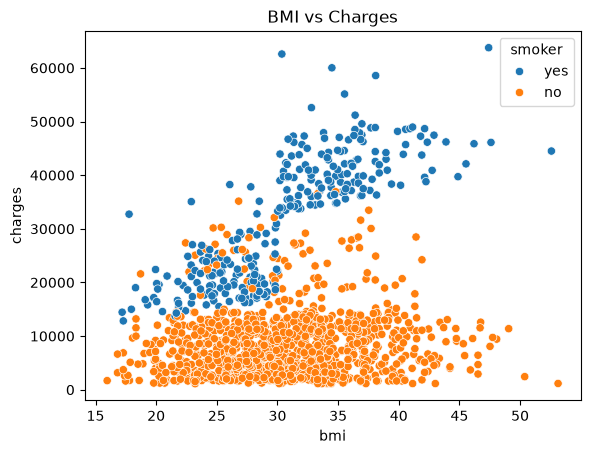

               age       bmi  children   charges
age       1.000000  0.109272  0.042469  0.299008
bmi       0.109272  1.000000  0.012759  0.198341
children  0.042469  0.012759  1.000000  0.067998
charges   0.299008  0.198341  0.067998  1.000000


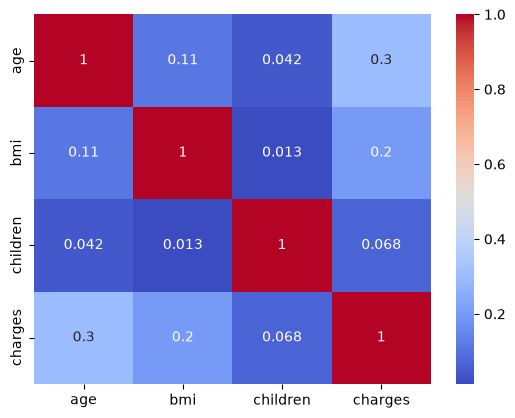

In [11]:
sns.scatterplot(data=df, x="bmi", y="charges", hue="smoker")
plt.title("BMI vs Charges")
plt.show()

corr = df[["age", "bmi", "children", "charges"]].corr()
print(corr)

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

In [15]:
from scipy import stats

smoker_charges = df.loc[df.smoker == "yes", "charges"]
nonsmoker_charges = df.loc[df.smoker == "no", "charges"]

print(stats.shapiro(smoker_charges))
print(stats.shapiro(nonsmoker_charges))

ShapiroResult(statistic=np.float64(0.9395519382929163), pvalue=np.float64(3.624989722535372e-09))
ShapiroResult(statistic=np.float64(0.8728637657660203), pvalue=np.float64(1.4459006863640269e-28))


In [16]:
print(stats.levene(smoker_charges,nonsmoker_charges))

LeveneResult(statistic=np.float64(332.6135162726081), pvalue=np.float64(1.5593284881791394e-66))


In [17]:
u_stat, p_val = stats.mannwhitneyu(smoker_charges, nonsmoker_charges, alternative="two-sided")
print(u_stat, p_val)

284133.0 5.270233444503571e-130


In [18]:
groups = [df.loc[df.region == r, "charges"] for r in df.region.unique()]
f_stat, p_val = stats.f_oneway(*groups)
print(f_stat, p_val)

2.96962669358912 0.03089335607049739


In [20]:
import statsmodels.formula.api as smf

formula = "charges ~ age + bmi + children + C(sex) + C(smoker) + C(region) + bmi:C(smoker)"
model = smf.ols(formula=formula, data=df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.841
Model:                            OLS   Adj. R-squared:                  0.840
Method:                 Least Squares   F-statistic:                     780.0
Date:                Tue, 08 Sep 2026   Prob (F-statistic):               0.00
Time:                        11:16:20   Log-Likelihood:                -13248.
No. Observations:                1338   AIC:                         2.652e+04
Df Residuals:                    1328   BIC:                         2.657e+04
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept              -2223

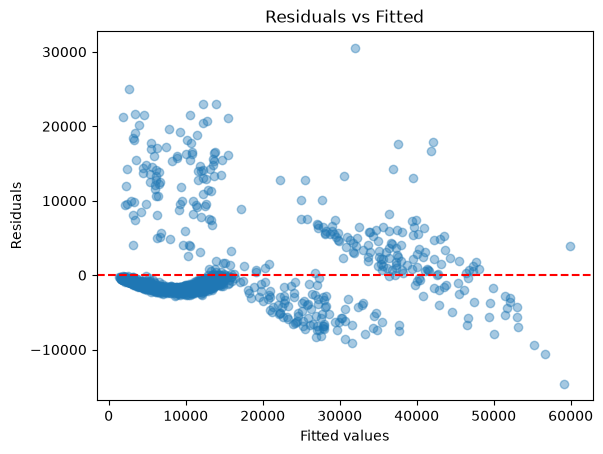

In [21]:
fitted = model.fittedvalues
resid = model.resid

import matplotlib.pyplot as plt
plt.scatter(fitted, resid, alpha=0.4)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")
plt.show()

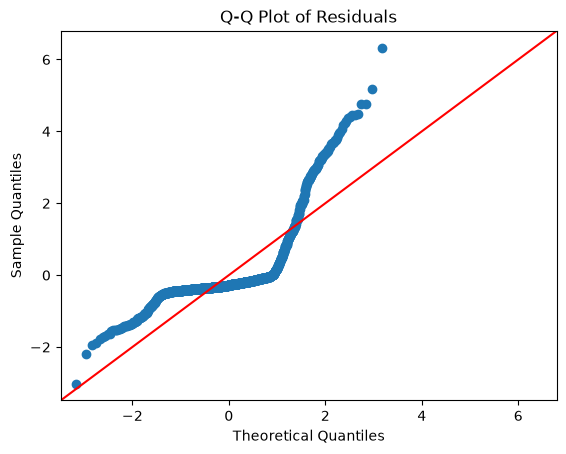

In [22]:
import statsmodels.api as sm
sm.qqplot(resid, line="45", fit=True)
plt.title("Q-Q Plot of Residuals")
plt.show()

In [23]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = sm.add_constant(df[["age", "bmi", "children"]])
vif_data = pd.DataFrame()
vif_data["feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
print(vif_data)

    feature       VIF
0     const  1.000000
1       age  1.013816
2       bmi  1.012152
3  children  1.001874
